# single_grid — the whole evolution in ONE circuit, no state tomography

The enhanced algorithm as implemented in `circuit.ipynb` reads the state out after every step and feeds
it back in. That read-out is a **simulator convenience, not physics** — but as written it would need
state tomography on hardware, which is exactly what we want to avoid.

This notebook builds the propagation as **one continuous circuit**: load $\rho(0)$ at the start, run to
$t=T$ for any $T$, and never reconstruct or re-prepare the system in between.

Two routes, because the Markovian and the non-Markovian case are structurally different:

| | route | ancilla | measurement of the system | success prob. |
|---|---|---|---|---|
| **Lindblad** (CPTP) | **Stinespring**: unitary + discard the environment | env register, reset each step | **never** | **1** |
| **HEOM / path integral** (non-CP) | **Sz.-Nagy** on the Krylov-compressed operator | 1 qubit, measured each step | **never** | $\approx0.33$ |

**Why the two must differ — a structural fact.** A CPTP map applied over and over to the *system alone*
is a semigroup, i.e. Markovian by construction. So non-Markovian dynamics needs either a coherent memory
register (which contains bath in qubits -> expensive but CP) or non-CP (like $E(\Delta t)$) operations (= post-selection = measure the ancilla after every step. If it is $\ket{1}$ terminate). There is no third option. Lindblad is CPTP, so it gets
the deterministic route; the memory-enhanced operator $E$ is not, so it keeps one ancilla measurement per
step. Since $E(\Delta t)$ is not CP (since we cut off the bath) we must use Sz.-Nagy instead of stinespring.

**That ancilla measurement is not tomography.** It is a single-qubit read-out that never touches the
system/memory register, and the register is never re-prepared. Runs where the ancilla comes out
$|1\rangle$ are simply discarded. This is one continuous grid in the sense you asked for.

**On the intermediate states.** In the simulator, snapshots give $\rho(t)$ for *every* $t$ from a single
execution. On hardware that is impossible in one run — measuring at time $t$ collapses the state, so you
would run the same circuit once per target $T$ (each run still internally continuous, still no
tomography). The functions below take `n_steps`, so any $T=n\,\Delta t$ works.

---
# Theory

Everything below is derived from scratch. Every statement that is not a definition or an immediate
consequence of one is proved, and the proofs are written out rather than cited, so that each formula
that appears in the code can be traced back to its origin. Throughout, $\mathcal H\cong\mathbb C^{d}$ is
the $d$-site system space, $D=d^2$, and $\|\cdot\|_2$ denotes the operator (spectral) norm and
$\|\cdot\|$ the Euclidean vector norm.

## 1. Vectorisation, the dynamical map, and its operator-sum form

### 1.1 The column-stacking isomorphism

> **Lemma 1.** For all $A,B,X\in\mathbb C^{d\times d}$,
> $$\operatorname{vec}(AXB)=\big(B^{\mathsf T}\otimes A\big)\operatorname{vec}(X).$$

### 1.2 The map and its matrix

The reduced state obeys $\rho(t)=\Phi_t[\rho(0)]$ with $\Phi_t$ linear, so there is a matrix
$\mathcal L(t)\in\mathbb C^{D\times D}$ with
$$\operatorname{vec}\big(\rho(t)\big)=\mathcal L(t)\operatorname{vec}\big(\rho(0)\big),\qquad
\mathcal L(t)_{\,ab}=\Big[\operatorname{vec}\Phi_t\big(\operatorname{unvec}(e_b)\big)\Big]_a,$$
i.e. the $b$-th column of $\mathcal L$ is the image of the $b$-th matrix unit. This is precisely what
`main.ipynb` stores: $e^{Lt}$ for Lindblad, the zeroth-ADO block of $e^{\hat{\mathcal L}_{\rm HEOM}t}$
for HEOM, and the contracted influence functional for TEMPO.

Wir haben in $D=d^2=4$: $$e_1 = \begin{pmatrix} 1 \\ 0 \\ 0 \\ 0 \end{pmatrix}, \quad e_2 = \begin{pmatrix} 0 \\ 1 \\ 0 \\ 0 \end{pmatrix}, \quad e_3 = \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix}, \quad e_4 = \begin{pmatrix} 0 \\ 0 \\ 0 \\ 1 \end{pmatrix} \quad \operatorname{unvec}(e_3) = \begin{pmatrix} 0 & 1 \\ 0 & 0 \end{pmatrix}$$

Nehmen wir eine unbekannte $4 \times 4$ Matrix $\mathcal{L}$ und multiplizieren sie mit dem dritten Standardbasisvektor $e_3$:$$\mathcal{L} \cdot e_3 = \begin{pmatrix} \mathcal{L}_{11} & \mathcal{L}_{12} & \mathcal{L}_{13} & \mathcal{L}_{14} \\ \mathcal{L}_{21} & \mathcal{L}_{22} & \mathcal{L}_{23} & \mathcal{L}_{24} \\ \mathcal{L}_{31} & \mathcal{L}_{32} & \mathcal{L}_{33} & \mathcal{L}_{34} \\ \mathcal{L}_{41} & \mathcal{L}_{42} & \mathcal{L}_{43} & \mathcal{L}_{44} \end{pmatrix} \begin{pmatrix} 0 \\ 0 \\ 1 \\ 0 \end{pmatrix} = \begin{pmatrix} \mathcal{L}_{13} \\ \mathcal{L}_{23} \\ \mathcal{L}_{33} \\ \mathcal{L}_{43} \end{pmatrix}$$

Das Ergebnis ist exakt die 3. Spalte von $\mathcal{L}$. Allgemein gilt für jeden Basisvektor $e_b$:$$\mathcal{L} \cdot e_b = \text{die } b\text{-te Spalte von } \mathcal{L}$$

Laut deiner Definition ist $\mathcal{L}(t)$ genau die Matrix-Darstellung der linearen physikalischen Abbildung $\Phi_t$ im vektorisierten Raum. Das bedeutet, das Verhalten von $\mathcal{L}$ auf einen Vektor ist exakt definiert als das Verhalten von $\Phi_t$ auf die entsprechende Matrix:$$\mathcal{L}(t) \cdot \operatorname{vec}(\rho) \equiv \operatorname{vec}\big( \Phi_t[\rho] \big) = \rho(t)$$

Setzen wir also spezifisch $\operatorname{vec}(\rho) = e_b$ (bzw. $\rho = \operatorname{unvec}(e_b) = E_{ij}$) in diese Gleichung ein:$$\underbrace{\mathcal{L}(t) \cdot e_b}_{\text{Die } b\text{-te Spalte von } \mathcal{L}(t)} = \operatorname{vec}\Big( \Phi_t\big[\operatorname{unvec}(e_b)\big] \Big)$$

Deine Dichtematrix ist eine Linearkombination aus diesen Matrixeinheiten. Wenn du ein Qubit hast, kannst du jede Dichtematrix schreiben als:$$\rho = \rho_{11} E_{11} + \rho_{12} E_{12} + \rho_{21} E_{21} + \rho_{22} E_{22}$$Da die Zeitentwicklung $\Phi_t$ linear ist (Superpositionsprinzip), gilt:$$\Phi_t[\rho] = \rho_{11} \Phi_t[E_{11}] + \rho_{12} \Phi_t[E_{12}] + \rho_{21} \Phi_t[E_{21}] + \rho_{22} \Phi_t[E_{22}]$$Wenn du die Evolution für die vier elementaren Bausteine $\Phi_t[E_{ij}]$ einmal berechnet und als Spalten in $\mathcal{L}(t)$ abgespeichert hast, musst du für keinen zukünftigen Anfangszustand $\rho(0)$ jemals wieder eine aufwendige Differentialgleichung (wie HEOM oder TEMPO) lösen!Du nimmst einfach deinen neuen Anfangszustand, wirfst ihn in die Vektorform und machst eine simple, extrem schnelle Matrix-Vektor-Multiplikation:$$\operatorname{vec}\big(\rho(t)\big) = \mathcal{L}(t) \cdot \operatorname{vec}\big(\rho(0)\big)$$

### 1.3 From the matrix to Kraus operators

A matrix is not yet something a circuit can apply. The bridge is the **Choi matrix**
$$C(\Phi):=\sum_{i,j=0}^{d-1}E_{ij}\otimes\Phi(E_{ij})\in\mathbb C^{D\times D},
\qquad (E_{ij})_{kl}=\delta_{ik}\delta_{jl},$$
so that $C$ read as a $d\times d$ array of $d\times d$ blocks has $\Phi(E_{ij})$ in block $(i,j)$, i.e.
$$C_{(i,a),(j,b)}=\big[\Phi(E_{ij})\big]_{ab}.$$

> **Proposition 2 (Choi).** $\Phi$ admits an operator-sum representation
> $\Phi(\rho)=\sum_kM_k\rho M_k^\dagger$ if and only if $C(\Phi)\succeq0$. In that case, writing the
> spectral decomposition $C=\sum_k\sigma_k\,u_ku_k^\dagger$ with $\sigma_k\ge0$ and setting
> $$(M_k)_{ai}:=\sqrt{\sigma_k}\,(u_k)_{(i,a)},$$
> one has $\Phi(\rho)=\sum_kM_k\rho M_k^\dagger$.

*Proof.* Suppose $C\succeq0$ and put $v_k:=\sqrt{\sigma_k}\,u_k$, so $C=\sum_kv_kv_k^\dagger$. Reading
off the entries,
$$C_{(i,a),(j,b)}=\sum_k (v_k)_{(i,a)}\overline{(v_k)_{(j,b)}}=\sum_k (M_k)_{ai}\overline{(M_k)_{bj}}
=\sum_k (M_k)_{ai}\,(M_k^\dagger)_{jb}.$$
On the other hand $\big[M_kE_{ij}M_k^\dagger\big]_{ab}=\sum_{p,q}(M_k)_{ap}(E_{ij})_{pq}(M_k^\dagger)_{qb}
=(M_k)_{ai}(M_k^\dagger)_{jb}$. Hence
$\big[\Phi(E_{ij})\big]_{ab}=\big[\sum_kM_kE_{ij}M_k^\dagger\big]_{ab}$ for all $i,j,a,b$. Since the
$E_{ij}$ span $\mathbb C^{d\times d}$ and both sides are linear in the argument, the identity extends to
every $\rho$. Conversely, if $\Phi(\rho)=\sum_kM_k\rho M_k^\dagger$ then reversing the computation
exhibits $C=\sum_kv_kv_k^\dagger\succeq0$. $\;\blacksquare$

> **Proposition 3.** $\Phi$ is trace preserving if and only if $\sum_kM_k^\dagger M_k=\mathbb 1$.

*Proof.* Using cyclicity, $\operatorname{Tr}\Phi(\rho)=\sum_k\operatorname{Tr}(M_k\rho M_k^\dagger)
=\operatorname{Tr}\big[(\sum_kM_k^\dagger M_k)\rho\big]$. This equals $\operatorname{Tr}\rho
=\operatorname{Tr}[\mathbb 1\rho]$ for **every** $\rho$ iff $\operatorname{Tr}[(\sum_kM_k^\dagger M_k-\mathbb 1)\rho]=0$
for every $\rho$; since $(X,Y)\mapsto\operatorname{Tr}(X^\dagger Y)$ is a nondegenerate inner product on
matrices, this forces $\sum_kM_k^\dagger M_k=\mathbb 1$. $\;\blacksquare$

These three statements are exactly `grid.ipynb`'s `choi_from_map`, `kraus_from_choi` and the closure
check that the validation cell reports at $1.8\times10^{-15}$.

## 2. Why reusing one channel can only ever give Markovian dynamics

The enhanced algorithm builds the Kraus operators of the one-step map $\mathcal L(\Delta t)$ once and
re-applies them, $\rho_n=\Phi_{\Delta t}^{\,n}(\rho_0)$. This is faithful precisely when the map family
is a semigroup, $\mathcal L(n\Delta t)=\mathcal L(\Delta t)^n$, which holds identically for a Lindblad
generator, $e^{Ln\Delta t}=(e^{L\Delta t})^n$, and fails for HEOM and the path integral, where we
measured $\max_n\|\mathcal L(n\Delta t)-\mathcal L(\Delta t)^n\|\approx0.4$.

The failure is structural, and the following statement is the reason this notebook has two routes
rather than one. Recall the standard definition: a discrete family $\{\Lambda_n\}_{n\ge0}$ with
$\Lambda_0=\mathrm{id}$ is **CP-divisible** (equivalently, Markovian in the divisibility sense) if for
all $m\le n$ there exists a completely positive $V_{n,m}$ with $\Lambda_n=V_{n,m}\circ\Lambda_m$.

> **Theorem 4.** Let $\Phi$ be any CPTP map on the system alone and let $\Lambda_n:=\Phi^n$. Then
> $\{\Lambda_n\}$ is CP-divisible. Consequently no choice of Kraus operators $\{M_k\}$ whatsoever can
> make the repeated application of a *system-only* channel non-Markovian.

*Proof.* For $m\le n$ put $V_{n,m}:=\Phi^{\,n-m}$. Then $\Lambda_n=\Phi^{n}=\Phi^{\,n-m}\circ\Phi^{m}
=V_{n,m}\circ\Lambda_m$. It remains to note that $V_{n,m}$ is completely positive: if $\Phi(\cdot)=\sum_kM_k\cdot M_k^\dagger$
then $\Phi^2(\cdot)=\sum_{k,l}M_lM_k\cdot M_k^\dagger M_l^\dagger$, which is again of operator-sum form
with Kraus operators $\{M_lM_k\}$, and by induction so is every power. By Proposition 2 each $\Phi^j$ is
therefore completely positive. $\;\blacksquare$

The theorem tells us where memory must come from. If the per-step operation is CP and acts on the system
alone, the dynamics is Markovian, full stop. To obtain non-Markovian behaviour exactly one of the two
hypotheses must be dropped: either the operation ceases to act on the system alone — it acts on the
system *together with a register carried along*, which is route A's mechanism generalised, and which we
implement in §3 and §6 — or the per-step operation ceases to be CP, which is route B and which we shall
see costs post-selection. There is no third possibility.

## 3. Transfer tensors and the companion operator

Write $\mathcal L_n:=\mathcal L(n\Delta t)$, with $\mathcal L_0=\mathbb 1$. We look for operators $T_m$
that reproduce the exact map at every time through a convolution over the past,
$$\mathcal L_n=\sum_{m=1}^{n}T_m\,\mathcal L_{n-m},\qquad n\ge1. \tag{3.1}$$

> **Proposition 5.** Equation (3.1) determines the $T_n$ uniquely, by the recursion
> $$T_n=\mathcal L_n-\sum_{m=1}^{n-1}T_m\,\mathcal L_{n-m}. \tag{3.2}$$

*Proof.* Isolate the $m=n$ term of (3.1) and use $\mathcal L_0=\mathbb 1$:
$\mathcal L_n=T_n\mathcal L_0+\sum_{m=1}^{n-1}T_m\mathcal L_{n-m}=T_n+\sum_{m=1}^{n-1}T_m\mathcal L_{n-m}$.
Solving for $T_n$ gives (3.2), and since the right-hand side involves only $T_1,\dots,T_{n-1}$, induction
on $n$ yields existence and uniqueness. In particular $T_1=\mathcal L_1$. $\;\blacksquare$

No approximation has been made: (3.1) is an identity. The approximation enters only when the convolution
is truncated at a finite depth $K$,
$$\operatorname{vec}\rho_{n+1}=\sum_{m=1}^{K}T_m\operatorname{vec}\rho_{\,n+1-m}, \tag{3.3}$$
which is legitimate because $\|T_m\|$ decays; the memory figure in `results.ipynb` shows three orders of
magnitude across the window.

Equation (3.3) is a linear difference equation of order $K$. Any such equation becomes first order once
the state is enlarged to carry the whole window. Set
$$X_n:=\begin{pmatrix}\operatorname{vec}\rho_n\\ \operatorname{vec}\rho_{n-1}\\ \vdots\\
\operatorname{vec}\rho_{n-K+1}\end{pmatrix}\in\mathbb C^{KD},
\qquad
E:=\begin{pmatrix}
T_1&T_2&\cdots&T_{K-1}&T_K\\
\mathbb 1&0&\cdots&0&0\\
0&\mathbb 1&\cdots&0&0\\
\vdots& &\ddots& &\vdots\\
0&0&\cdots&\mathbb 1&0
\end{pmatrix}. \tag{3.4}$$

> **Proposition 6.** The sequence $\{\rho_n\}$ satisfies (3.3) if and only if $X_{n+1}=EX_n$ for all $n$.
> Moreover $\operatorname{vec}\rho_n=\Pi X_n$ with $\Pi:=(\mathbb 1\;0\;\cdots\;0)$, and consequently
> $$\operatorname{vec}\rho_{\,n}= \Pi\,E^{\,n-K+1}X_{K-1}. \tag{3.5}$$

*Proof.* Denote by $(X)_r$, $r=1,\dots,K$, the $r$-th block of a stacked vector, so
$(X_n)_r=\operatorname{vec}\rho_{\,n-r+1}$. Applying (3.4), the first block of $EX_n$ is
$\sum_{m=1}^{K}T_m(X_n)_m=\sum_{m=1}^{K}T_m\operatorname{vec}\rho_{\,n-m+1}$, which by (3.3) equals
$\operatorname{vec}\rho_{\,n+1}=(X_{n+1})_1$. For $r\ge2$ the $r$-th block row of $E$ picks out
$(X_n)_{r-1}=\operatorname{vec}\rho_{\,n-r+2}$, and indeed
$(X_{n+1})_r=\operatorname{vec}\rho_{\,n+1-r+1}=\operatorname{vec}\rho_{\,n-r+2}$. Both blocks agree, so
$X_{n+1}=EX_n$; the converse is read off the same two identities. The projection statement is the
definition of $(X_n)_1$, and (3.5) follows by iterating. $\;\blacksquare$

This $E$ is what `companion_propagator` builds and what the non-Markovian circuit must apply repeatedly.
Two features of (3.4) will matter later: $E$ is *not* a channel — it acts on a stack of vectorised
density matrices, it is not positive, and Proposition 2 does not apply to it — and its lower block rows
are isometries that merely shift the window, which is what makes its operator norm exceed one (§6.1).

## 4. Route A — Stinespring dilation: deterministic, nothing is measured

For a map that *is* CPTP the enlargement demanded by Theorem 4 comes for free, and it costs no
post-selection whatsoever.

### 4.1 The isometry

Let $\{M_k\}_{k=1}^{K}$ be Kraus operators of a CPTP map $\Phi$, and let $\mathcal H_E\cong\mathbb C^{K}$
carry an orthonormal basis $\{|k\rangle\}$. Define
$$V:\mathcal H\to\mathcal H_E\otimes\mathcal H,\qquad
V|\psi\rangle:=\sum_{k=1}^{K}|k\rangle_E\otimes M_k|\psi\rangle. \tag{4.1}$$

> **Proposition 7.** $V$ is an isometry, $V^\dagger V=\mathbb 1$, and
> $\operatorname{Tr}_E\!\big[V\rho V^\dagger\big]=\Phi(\rho)$ for every $\rho$.

*Proof.* For the first claim,
$$\langle\varphi|V^\dagger V|\psi\rangle=\sum_{k,k'}\langle k|k'\rangle\,\langle\varphi|M_k^\dagger M_{k'}|\psi\rangle
=\Big\langle\varphi\Big|\Big(\sum_kM_k^\dagger M_k\Big)\Big|\psi\Big\rangle=\langle\varphi|\psi\rangle,$$
where the last step is Proposition 3. For the second, expand
$V\rho V^\dagger=\sum_{k,k'}|k\rangle\langle k'|\otimes M_k\rho M_{k'}^\dagger$ and take the partial
trace over $E$, which acts as $\operatorname{Tr}_E\big[|k\rangle\langle k'|\otimes Y\big]
=\operatorname{Tr}(|k\rangle\langle k'|)\,Y=\delta_{kk'}Y$. Only the diagonal terms survive and
$\operatorname{Tr}_E[V\rho V^\dagger]=\sum_kM_k\rho M_k^\dagger=\Phi(\rho)$. $\;\blacksquare$

Note that the isometry property is *identical* to the trace-preservation condition — the same equation
$\sum_kM_k^\dagger M_k=\mathbb 1$ that Proposition 3 produced. This is why nothing has to be paid for
here, and the code confirms it numerically at $1.8\times10^{-15}$.

### 4.2 Completion to a gate

An isometry is not yet a unitary, but it extends to one.

> **Proposition 8.** Let $V\in\mathbb C^{N\times d}$ with $V^\dagger V=\mathbb 1_d$ and $N\ge d$. Then
> there exists a unitary $U\in\mathrm U(N)$ whose first $d$ columns are those of $V$; equivalently
> $$U\big(|0\rangle_E\otimes|\psi\rangle\big)=V|\psi\rangle\qquad\text{for all }|\psi\rangle\in\mathbb C^d. \tag{4.2}$$

*Proof.* The columns $v_1,\dots,v_d$ of $V$ are orthonormal in $\mathbb C^N$, because
$(V^\dagger V)_{ab}=\langle v_a,v_b\rangle=\delta_{ab}$. Any orthonormal set extends to an orthonormal
basis: choose an orthonormal basis $w_1,\dots,w_{N-d}$ of the orthogonal complement
$\operatorname{range}(V)^{\perp}$, which has dimension $N-d$, and set $U:=[\,v_1\cdots v_d\,|\,w_1\cdots w_{N-d}\,]$.
Its columns form an orthonormal basis, hence $U^\dagger U=\mathbb 1_N$. Applying $U$ to the $a$-th
standard basis vector returns its $a$-th column; since $|0\rangle_E\otimes|\psi\rangle$ has support only
on the first $d$ coordinates with coefficients $\psi_a$, linearity gives (4.2). $\;\blacksquare$

In the code the complement is obtained with `scipy.linalg.null_space(V.conj().T)`, whose columns span
$\ker(V^\dagger)=\operatorname{range}(V)^{\perp}$.

### 4.3 The channel as a gate plus a reset

Combining Propositions 7 and 8,
$$\boxed{\;\Phi(\rho)=\operatorname{Tr}_E\!\Big[U\big(|0\rangle\langle0|_E\otimes\rho\big)U^\dagger\Big]\;}
\tag{4.3}$$
because $U(|0\rangle\langle0|\otimes\rho)U^\dagger=V\rho V^\dagger$ by (4.2). The partial trace is
implemented physically by a **reset**: discarding the environment and re-preparing it in $|0\rangle$ is
the operation $\sigma\mapsto\operatorname{Tr}_E[\sigma]\otimes|0\rangle\langle0|$, whose system marginal
is exactly $\operatorname{Tr}_E[\sigma]$. No measurement outcome is selected and nothing is discarded
conditionally, so the step succeeds with probability $1$ — formally, (4.3) is trace preserving by
Proposition 3, and a trace-preserving evolution has no failure branch.

> **Proposition 9.** Let the circuit apply $U$ and then reset $E$, $n$ times in succession, starting from
> $|0\rangle\langle0|_E\otimes\rho_0$. Then the system register carries $\Phi^n(\rho_0)$, and a single
> environment register suffices.

*Proof.* By induction. After the first block the system marginal is $\Phi(\rho_0)$ by (4.3), and the
reset has restored $E$ to $|0\rangle\langle0|$ *uncorrelated* with the system, since the reset output is
by construction a product $\operatorname{Tr}_E[\sigma]\otimes|0\rangle\langle0|$. The state entering
block $j+1$ is therefore again of the form $|0\rangle\langle0|_E\otimes\rho_j$, so (4.3) applies verbatim
and yields $\rho_{j+1}=\Phi(\rho_j)$. Because the environment is restored to a fixed product state each
time, the same physical register can be reused. $\;\blacksquare$

### 4.4 Index conventions

Definition (4.1) implies that the composite index of $V|\psi\rangle$ is $k\cdot 2^{\,n_{\rm sys}}+i$, with
the environment as the *more significant* register. Qiskit numbers qubits so that qubit $0$ is the least
significant bit of the statevector index; hence appending the gate to the system qubits **first** and the
environment qubits second reproduces exactly this ordering. That is the reason the code reads
`qc.append(gate, sys_q + env_q)` and not the reverse — with the operands exchanged the gate would
implement a different, wrong map.

## 5. Route B — Sz.-Nagy dilation and the price of non-complete-positivity

The companion operator $E$ of §3 is not a channel, so Proposition 7 is unavailable and we must use the
weaker dilation that works for *any* contraction.

### 5.1 When the square roots exist

> **Lemma 10.** $\mathbb 1-AA^\dagger\succeq0$ if and only if $\|A\|_2\le1$, and likewise for
> $\mathbb 1-A^\dagger A$.

*Proof.* For any $x$, $\langle x,(\mathbb 1-AA^\dagger)x\rangle=\|x\|^2-\|A^\dagger x\|^2$, which is
non-negative for all $x$ exactly when $\|A^\dagger\|_2\le1$. Since $\|A^\dagger\|_2=\|A\|_2$ the claim
follows; the second statement is the same computation with $A$ and $A^\dagger$ exchanged. $\;\blacksquare$

Both operators are Hermitian and positive semidefinite, so their unique positive square roots
$B:=\sqrt{\mathbb 1-AA^\dagger}$ and $C:=\sqrt{\mathbb 1-A^\dagger A}$ exist. For a general $A$ one first
rescales by any $s\ge\|A\|_2$; the code uses $s=\|A\|_2(1+10^{-12})$.

### 5.2 The dilation is unitary

> **Lemma 11 (intertwining).** For every continuous $f$ on $[0,\|A\|_2^2]$,
> $$A^\dagger f(AA^\dagger)=f(A^\dagger A)\,A^\dagger .$$

*Proof.* First for monomials, by induction on $k$: for $k=0$ the claim is trivial, and
$$A^\dagger (AA^\dagger)^{k+1}=\big(A^\dagger (AA^\dagger)^{k}\big)AA^\dagger
=(A^\dagger A)^{k}A^\dagger AA^\dagger=(A^\dagger A)^{k+1}A^\dagger .$$
By linearity the identity holds for every polynomial $p$. Now let $f$ be continuous on the (compact)
spectrum. By Weierstrass approximation there are polynomials $p_n\to f$ uniformly there, and for
Hermitian $H$ the functional calculus obeys $\|p_n(H)-f(H)\|_2=\max_{\lambda\in\operatorname{spec}H}|p_n(\lambda)-f(\lambda)|\to0$.
Since $AA^\dagger$ and $A^\dagger A$ have the same spectrum up to the eigenvalue $0$, both sides converge
in norm and the identity passes to the limit. $\;\blacksquare$

> **Theorem 12 (Sz.-Nagy).** For $\|A\|_2\le1$ the block matrix
> $$U=\begin{pmatrix}A&B\\ C&-A^\dagger\end{pmatrix},\qquad
> B=\sqrt{\mathbb 1-AA^\dagger},\quad C=\sqrt{\mathbb 1-A^\dagger A},$$
> is unitary.

*Proof.* Compute the three independent blocks of $U^\dagger U$, using $B^\dagger=B$, $C^\dagger=C$:
$$\begin{aligned}
(1,1):\quad & A^\dagger A+C^\dagger C=A^\dagger A+(\mathbb 1-A^\dagger A)=\mathbb 1,\\
(2,2):\quad & B^\dagger B+(-A)(-A^\dagger)=(\mathbb 1-AA^\dagger)+AA^\dagger=\mathbb 1,\\
(1,2):\quad & A^\dagger B-C\,A^\dagger
=A^\dagger\sqrt{\mathbb 1-AA^\dagger}-\sqrt{\mathbb 1-A^\dagger A}\,A^\dagger=0,
\end{aligned}$$
the last line being Lemma 11 with $f(x)=\sqrt{1-x}$, which is continuous on $[0,1]\supseteq\operatorname{spec}(AA^\dagger)$.
The block $(2,1)$ is the adjoint of $(1,2)$ and vanishes as well. $\;\blacksquare$

### 5.3 Post-selection and its probability

Prepare the ancilla in $|0\rangle$ and the register in $|x\rangle$ with $\|x\|=1$. In the block notation
this is the vector $(x,0)^{\mathsf T}$, and
$$U\begin{pmatrix}x\\0\end{pmatrix}=\begin{pmatrix}(A/s)\,x\\ C\,x\end{pmatrix}. \tag{5.1}$$
The two components are the ancilla-$|0\rangle$ and ancilla-$|1\rangle$ branches. Their norms add up
correctly, as they must:
$$\|(A/s)x\|^2+\|Cx\|^2=\big\langle x,(A/s)^\dagger(A/s)x\big\rangle+\big\langle x,(\mathbb 1-(A/s)^\dagger(A/s))x\big\rangle=\|x\|^2 .$$
By the Born rule, measuring the ancilla yields $|0\rangle$ with probability
$$p=\big\|(A/s)x\big\|^2=\frac{\|Ax\|^2}{s^2\|x\|^2}, \tag{5.2}$$
and conditioned on that outcome the register is left in $(A/s)x$ normalised — that is, in $Ax/\|Ax\|$.
Post-selection therefore applies $A$ *up to normalisation*, which is all we need because the physical
scale is tracked classically (§5.5).

### 5.4 Many steps

> **Proposition 13.** Let $x_{t+1}:=Ax_t$ denote the unnormalised iterates and let the circuit apply the
> dilation $n$ times, each with its own ancilla, post-selecting every ancilla on $|0\rangle$. Then
> $$p_{\rm total}=\prod_{t=0}^{n-1}p_t=\frac{\|A^{n}x_0\|^{2}}{s^{2n}\|x_0\|^{2}}. \tag{5.3}$$

*Proof.* Let $y_t:=x_t/\|x_t\|$ be the normalised register state entering step $t$. By (5.2),
$$p_t=\frac{\|Ay_t\|^2}{s^2}=\frac{\|Ax_t\|^2}{s^2\|x_t\|^2}=\frac{\|x_{t+1}\|^2}{s^2\|x_t\|^2}.$$
The product telescopes,
$$\prod_{t=0}^{n-1}p_t=\frac{1}{s^{2n}}\prod_{t=0}^{n-1}\frac{\|x_{t+1}\|^2}{\|x_t\|^2}
=\frac{1}{s^{2n}}\cdot\frac{\|x_n\|^2}{\|x_0\|^2},$$
and $x_n=A^nx_0$. $\;\blacksquare$

Whether the ancillas are measured immediately after their own step or all together at the end is
immaterial: once step $t$ is over, no later gate touches ancilla $t$, so the measurement commutes with
everything that follows and the joint outcome statistics are unchanged. This is the deferred-measurement
principle, and it is what makes the construction *one* circuit rather than $n$ conditionally restarted
ones.

Formula (5.3) is the entire difficulty of route B. For our companion operator $\|E\|_2=\sqrt2$ while the
spectral radius is $\rho(E)=1$, so with $n=76$ steps
$$p_{\rm total}\simeq\frac{\mathcal O(1)}{2^{76}}\approx6.7\times10^{-24},$$
roughly $10^{23}$ shots per usable sample.

### 5.5 The classical scale factor

No renormalisation is performed on the quantum register — a quantum state is normalised by definition.
What must be tracked is the scalar $\lambda_t:=\|x_t\|$ relating the register state to the physical
amplitude, and it obeys a closed recursion:
$$\lambda_{t+1}=\|x_{t+1}\|=\|A x_t\|=s\sqrt{p_t}\;\|x_t\|=s\sqrt{p_t}\,\lambda_t ,$$
using (5.2) in the middle step. Since $p_t$ is estimated from the measured frequency of the $|0\rangle$
outcome at step $t$, the reconstruction $\operatorname{vec}\rho_t=\lambda_t\,\Pi\,y_t$ requires no
tomography — only counting.

## 6. The operator norm is the wrong quantity — compressing onto the reachable subspace

### 6.1 Where the $\sqrt2$ comes from, and why it is unphysical

The exponential in (5.3) is governed by $s=\|E\|_2$, which by definition is a supremum over the entire
register,
$$\|E\|_2=\sup_{X\neq0}\frac{\|EX\|}{\|X\|}.$$
The following computation shows precisely which $X$ attains it — and that no physical state is anywhere
near it.

> **Proposition 14.** Write $X=(x_1,\dots,x_K)$ in blocks. Then
> $$\|EX\|^2-\|X\|^2=\Big\|\sum_{m=1}^{K}T_mx_m\Big\|^2-\|x_K\|^2 . \tag{6.1}$$
> In particular $\|E\|_2^2\ge1+\|T_1\|_2^2$, with the lower bound approached on states supported on the
> first block alone.

*Proof.* By (3.4), $EX=\big(\sum_mT_mx_m,\;x_1,\;x_2,\dots,x_{K-1}\big)$. Blocks being orthogonal,
$$\|EX\|^2=\Big\|\sum_mT_mx_m\Big\|^2+\sum_{i=1}^{K-1}\|x_i\|^2,
\qquad \|X\|^2=\sum_{i=1}^{K}\|x_i\|^2,$$
and subtracting gives (6.1). For the bound take $X=(x,0,\dots,0)$ with $\|x\|=1$: then
$\|EX\|^2=\|T_1x\|^2+1$, and maximising over $x$ gives $\|E\|_2^2\ge\|T_1\|_2^2+1$. $\;\blacksquare$

Now recall from Proposition 5 that $T_1=\mathcal L_1=\mathcal L(\Delta t)$, the one-step map, which for a
small step is close to the identity and in particular has $\|T_1\|_2\approx1$. Proposition 14 therefore
*predicts* $\|E\|_2\approx\sqrt2$ — and this is exactly the value we measure. But the maximiser is the
state with only one populated block, i.e. a history window in which the system existed at one instant and
was identically zero at all $K-1$ earlier ones. That is not a physical configuration.

A physical $X$ has all $K$ blocks populated with comparable norms, $\|x_i\|=\|\rho_{n-i+1}\|_F\in[d^{-1/2},1]$,
and (6.1) then says that the norm changes only by the difference between the newly created slice and the
discarded oldest one, a difference spread over $K$ blocks. Hence the ratio stays near one, and indeed
along the trajectory we measure
$$\frac{\|EX_n\|}{\|X_n\|}\in[0.982,\,0.998],\qquad\text{mean }0.9955 .$$

### 6.2 Arnoldi compression

Let $\mathcal K_m(E,X_0):=\operatorname{span}\{X_0,EX_0,\dots,E^{m-1}X_0\}$ be the Krylov space, which by
construction contains the entire reachable trajectory. The Arnoldi process builds an orthonormal basis of
it: set $q_1:=X_0/\|X_0\|$ and, for $j=1,2,\dots$,
$$h_{ij}:=\langle q_i,Eq_j\rangle\;(i\le j),\qquad
w_j:=Eq_j-\sum_{i=1}^{j}h_{ij}q_i,\qquad
h_{j+1,j}:=\|w_j\|,\qquad q_{j+1}:=w_j/h_{j+1,j}. \tag{6.2}$$

> **Proposition 15.** With $Q_m:=(q_1\cdots q_m)$ and $H_m:=(h_{ij})_{i,j\le m}$ upper Hessenberg,
> $$E\,Q_m=Q_mH_m+h_{m+1,m}\,q_{m+1}e_m^{\mathsf T},\qquad H_m=Q_m^\dagger E\,Q_m . \tag{6.3}$$

*Proof.* Rearranging (6.2) gives $Eq_j=\sum_{i=1}^{j+1}h_{ij}q_i$, which for $j<m$ is column $j$ of
$Q_mH_m$ and for $j=m$ carries the extra term $h_{m+1,m}q_{m+1}$; collecting the columns yields the first
identity. Multiplying it by $Q_m^\dagger$ and using $Q_m^\dagger Q_m=\mathbb 1_m$ together with
$Q_m^\dagger q_{m+1}=0$ (the vectors are orthonormal by construction) gives the second. $\;\blacksquare$

> **Proposition 16.** $\|H_m\|_2\le\|E\|_2$.

*Proof.* For any $y\in\mathbb C^m$, $\|H_my\|=\|Q_m^\dagger EQ_my\|\le\|EQ_my\|\le\|E\|_2\|Q_my\|=\|E\|_2\|y\|$,
where the first inequality holds because $Q_m^\dagger$ is a contraction ($\|Q_m^\dagger\|_2=\|Q_m\|_2=1$
for an isometry) and the last equality because $Q_m$ preserves norms. $\;\blacksquare$

Proposition 16 only guarantees no increase; the useful statement is quantitative and follows from §6.1:
compression removes precisely the unvisited, norm-inflating directions identified in Proposition 14, and
numerically $\|H_{32}\|_2=1.0028$ against $\|E\|_2=1.4142$.

> **Proposition 17.** If $h_{m+1,m}=0$, then $\mathcal K_m$ is $E$-invariant and
> $$E^{\,n}X_0=\|X_0\|\,Q_mH_m^{\,n}e_1\qquad\text{for all }n\ge0. \tag{6.4}$$

*Proof.* With $h_{m+1,m}=0$, (6.3) reduces to $EQ_m=Q_mH_m$. Then $E^2Q_m=E Q_mH_m=Q_mH_m^2$, and
inductively $E^nQ_m=Q_mH_m^n$. Since $X_0=\|X_0\|\,q_1=\|X_0\|\,Q_me_1$, applying $E^n$ gives (6.4).
$\;\blacksquare$

When $h_{m+1,m}\neq0$ the deviation is controlled by that residual, which is why the trajectory error in
the table falls monotonically as $m$ grows.

### 6.3 The consequence, and the trade-off

Dilating $H_m$ rather than $E$ changes (5.3) from $s^{-2n}=2^{-n}$ to $\|H_m\|_2^{-2n}\approx1$. For
$n=76$ steps this turns
$$p_{\rm total}=6.7\times10^{-24}\quad\longrightarrow\quad p_{\rm total}=0.328,$$
three shots per sample, while simultaneously shrinking the register from $KD=400$ dimensions ($10$ qubits)
to $m=32$ ($6$ qubits including the ancilla). The physical state is recovered as
$\operatorname{vec}\rho_t=\lambda_t\,\Pi\,Q_m\,y_t$ with $\lambda_t$ the scalar of §5.5.

The choice of $m$ is a genuine trade-off, not a convergence parameter. Small $m$ truncates the trajectory
(the residual $h_{m+1,m}$ in Proposition 17 is large); large $m$ lets Arnoldi reach into the very
directions Proposition 14 identified as norm-inflating, so $\|H_m\|_2$ creeps up and (5.3) degrades again.
For HEOM the optimum is broad ($m=32$: error $1.5\times10^{-3}$, $p=0.33$); for the path integral, whose
$E$ is assembled from MPS-truncated maps and is markedly more non-normal, $m=64$ already gives
$\|H_m\|_2=1.243$ and hence $p=2.5\times10^{-18}$.

## 7. What is actually read out, and the question of intermediate times

The two routes differ in what the final measurement has to accomplish, and the difference is one of
encoding rather than of effort.

Route A stores $\rho$ *as a density matrix* on $n_{\rm sys}=\lceil\log_2d\rceil$ qubits. The populations
are then the diagonal, $p_i=\langle i|\rho|i\rangle$, which is precisely the outcome distribution of a
computational-basis measurement: repeating the circuit and histogramming the results estimates every
$p_i$ to accuracy $\varepsilon$ with $\mathcal O(1/\varepsilon^2)$ shots. No tomography is involved at
any stage, and coherences would require only the usual change of measurement basis.

Route B stores $\operatorname{vec}\rho$ *as amplitudes* of a normalised pure register state. A
computational-basis measurement returns $|(\operatorname{vec}\rho)_a|^2$ up to normalisation, so phases —
and hence the coherences — need amplitude estimation, for instance a Hadamard test against a reference
state. The essential point is that this happens **once, at the end of the run**, never between steps: the
$\lambda_t$ of §5.5 come from counting ancilla outcomes, not from reconstructing a state.

Finally the trajectory. The snapshots produced by the code come from the simulator instruction
`save_density_matrix`, which reads the simulator's own memory and has no physical counterpart. On
hardware a measurement at time $t$ collapses the state and the evolution cannot be continued, so the full
trajectory would cost one run per target $T$, each run internally continuous and tomography-free.

Whether all times can nevertheless be obtained from a *single* run with a *single* measurement is the
subject of §8, and the answer turns out to be yes, at a cost of only $\lceil\log_2(n+1)\rceil+1$
additional qubits.

---

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import sqrtm, null_space

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import UnitaryGate
from qiskit.quantum_info import DensityMatrix
from qiskit_aer import AerSimulator

import import_ipynb
from validation_and_helpers import load_run

N = 4
run = load_run(f'data/run_N{N}.npz')
d, D, t_fs = run['d'], run['d'] ** 2, run['t_fs']
res = run['res']
print(f'N = {N},  d = {d},  reference run loaded')

N = 4,  d = 4,  reference run loaded


## Route A — Lindblad: fully deterministic, nothing is measured

A CPTP map $\Phi(\rho)=\sum_k M_k\rho M_k^\dagger$ has a **Stinespring dilation**: an isometry
$V|\psi\rangle=\sum_k M_k|\psi\rangle|k\rangle$, extended to a unitary $U$ on
environment $\otimes$ system. Applying $U$ and then *discarding* the environment reproduces $\Phi$
exactly — discarding is a reset, not a measurement, so the step succeeds with probability $1$.

Iterating is then trivial: apply $U$, reset the environment register, repeat. The system register holds
$\rho(t)$ the whole time and is never touched.

In [ ]:
def stinespring_unitary(kraus, d):
    """U on (env (x) sys) with U(|0>_env (x) |psi>) = sum_k M_k|psi>|k>.

    The composite index is env*2^n_sys + sys, which is Qiskit's ordering when the
    system qubits are appended first (they are the low bits)."""
    n_sys = int(np.ceil(np.log2(d)))     
    Dp = 1 << n_sys
    n_env = int(np.ceil(np.log2(len(kraus))))
    Kp = 1 << n_env
    
    V = np.zeros((Kp * Dp, Dp), complex)
    for k, M in enumerate(kraus):
        V[k * Dp:k * Dp + d, :d] = M
    iso = V[:, :d]                                  # isometry on the physical subspace
    U = np.hstack([iso, null_space(iso.conj().T)])  # complete to a unitary
    return U, n_sys, n_env


def propagate_stinespring(kraus, d, n_steps, rho0=None):
    """ONE circuit, T = n_steps*dt, deterministic. Returns (pops, circuit, info).

    Nothing is measured and nothing is re-prepared: each step applies the same
    unitary and resets the environment (= traces it out)."""
    U, n_sys, n_env = stinespring_unitary(kraus, d)
    Dp = 1 << n_sys
    if rho0 is None:
        rho0 = np.zeros((Dp, Dp), complex); rho0[0, 0] = 1.0
    sys_q, env_q = list(range(n_sys)), list(range(n_sys, n_sys + n_env))

    env0 = np.zeros((1 << n_env, 1 << n_env), complex); env0[0, 0] = 1.0
    qc = QuantumCircuit(n_sys + n_env)
    qc.set_density_matrix(DensityMatrix(np.kron(env0, rho0)))   # env (x) sys
    qc.save_density_matrix(sys_q, label='t0')

    gate = UnitaryGate(U, label='Stinespring')
    for t in range(1, n_steps + 1):
        qc.append(gate, sys_q + env_q)
        qc.reset(env_q)                                # discard == trace out
        qc.save_density_matrix(sys_q, label=f't{t}')   # simulator snapshot

    data = AerSimulator(method='density_matrix').run(qc).result().data()
    rho = np.array([np.asarray(data[f't{t}']) for t in range(n_steps + 1)])
    pops = np.real(np.einsum('tii->ti', rho))[:, :d]
    return pops, qc, dict(rho=rho, n_sys=n_sys, n_env=n_env,
                          n_qubits=n_sys + n_env, p_success=1.0)

In [3]:
n_steps = len(t_fs) - 1                     # T = 1000 fs; any n_steps works
pops_A, qc_A, info_A = propagate_stinespring(res['Lindblad']['kraus_dt'], d, n_steps)

ref_A = res['Lindblad']['pops']
print(f"circuit : {info_A['n_qubits']} qubits "
      f"({info_A['n_sys']} system + {info_A['n_env']} environment), depth {qc_A.depth()}")
print(f"          {n_steps} gates, {n_steps} environment resets, "
      f"0 measurements, success probability {info_A['p_success']:.3f}")
print(f"accuracy: max |one-circuit - stored per-step result| = {np.abs(pops_A - ref_A).max():.2e}")
print(f"trace   : min over all {n_steps + 1} snapshots = "
      f"{np.real(np.trace(info_A['rho'], axis1=1, axis2=2)).min():.12f}")
print(f"pops(T) = {np.round(pops_A[-1], 4)}")

circuit : 6 qubits (2 system + 4 environment), depth 200
          100 gates, 100 environment resets, 0 measurements, success probability 1.000
accuracy: max |one-circuit - stored per-step result| = 1.72e-15
trace   : min over all 101 snapshots = 1.000000000000
pops(T) = [0.2701 0.4655 0.1001 0.1643]


## Route B — HEOM / path integral: one circuit, only the ancilla is measured

The memory-enhanced operator $E$ (transfer tensors on a $K$-step register) is **not** completely
positive, so no Stinespring dilation exists and post-selection is unavoidable. Done naively this is
hopeless: $\|E\|_2=\sqrt2$, so $76$ steps succeed with probability $\sim s^{-2n}=10^{-24}$.

But $\|E\|_2$ is a worst-case bound over the whole $K\!\cdot\!D$-dimensional register, and the physical
trajectory never goes there — along it, $\|EX\|/\|X\|\approx0.995$. So we first **compress $E$ onto the
reachable (Krylov) subspace** with Arnoldi, $H_m=Q_m^\dagger E Q_m$, which has $\|H_m\|_2\approx1.003$,
and dilate *that*. This shrinks the register **and** lifts the success probability by ~23 orders of
magnitude.

$m$ trades accuracy against cost: too small and the trajectory is wrong, too large and $H_m$ picks up
non-normal directions that push $\|H_m\|_2$ back up.

In [4]:
def arnoldi(E, x0, m):
    """Orthonormal basis Q_m of the Krylov space and H_m = Q_m^dag E Q_m."""
    Q = np.zeros((E.shape[0], m + 1), complex); Q[:, 0] = x0 / np.linalg.norm(x0)
    H = np.zeros((m + 1, m), complex); mm = m
    for j in range(m):
        w = E @ Q[:, j]
        for i in range(j + 1):
            H[i, j] = np.vdot(Q[:, i], w); w -= H[i, j] * Q[:, i]
        H[j + 1, j] = np.linalg.norm(w)
        if H[j + 1, j] < 1e-13:
            mm = j + 1; break
        Q[:, j + 1] = w / H[j + 1, j]
    return H[:mm, :mm], Q[:, :mm]


def dilate(A):
    """Sz.-Nagy: A/s as the top-left block of a unitary one qubit larger."""
    n = A.shape[0]; s = float(np.linalg.norm(A, 2)) * (1 + 1e-12); As = A / s
    I = np.eye(n)
    B = sqrtm(I - As @ As.conj().T); C = sqrtm(I - As.conj().T @ As)
    B, C = 0.5 * (B + B.conj().T), 0.5 * (C + C.conj().T)
    return np.block([[As, B], [C, -As.conj().T]]), s


def propagate_memory_single(E, X0, n_steps, m, d):
    """ONE circuit for the non-Markovian case. The memory register is never
    measured and never re-prepared; only the ancilla is read out each step and
    runs with a |1> outcome are discarded. Returns (pops, circuit, info)."""
    D = d * d
    Hm, Qm = arnoldi(E, X0, m); m = Hm.shape[0]
    mp = 1 << int(np.ceil(np.log2(m)))
    A = np.zeros((mp, mp), complex); A[:m, :m] = Hm
    U, s = dilate(A)
    nq = int(np.log2(mp))

    qr, ar = QuantumRegister(nq, 'mem'), QuantumRegister(1, 'anc')
    cr = ClassicalRegister(n_steps, 'ok')
    qc = QuantumCircuit(qr, ar, cr)
    y = np.zeros(mp, complex); y[0] = 1.0
    qc.initialize(np.concatenate([y, np.zeros(mp)]), list(qr) + list(ar))
    gate = UnitaryGate(U, label='H_m')
    for t in range(n_steps):
        qc.append(gate, list(qr) + list(ar))
        qc.measure(ar[0], cr[t])        # ONLY the ancilla
        qc.reset(ar[0])

    # the |0...0> branch the post-selection keeps, with the classical norm bookkeeping
    scale = np.linalg.norm(X0); yv = y.copy(); p_tot = 1.0
    pops = [np.real(np.diag((Qm @ yv[:m] * scale)[:D].reshape(d, d, order='F')))]
    for _ in range(n_steps):
        top = (U @ np.concatenate([yv, np.zeros(mp)]))[:mp]
        nrm = np.linalg.norm(top); p_tot *= nrm ** 2
        yv = top / nrm; scale = scale * nrm * s
        pops.append(np.real(np.diag((Qm @ yv[:m] * scale)[:D].reshape(d, d, order='F'))))
    return np.array(pops), qc, dict(m=m, n_qubits=nq + 1, s=s, p_success=p_tot,
                                    norm_Hm=float(np.linalg.norm(Hm, 2)))

In [5]:
M_KRYLOV = 32          # compression dimension: accuracy vs success probability
out_B = {}

for name in ('HEOM', 'Path integral'):
    E, K = res[name]['E'], res[name]['K']
    X0 = np.concatenate([res[name]['rho'][i].flatten(order='F') for i in range(K)][::-1])
    pops, qc, info = propagate_memory_single(E, X0, len(t_fs) - K, M_KRYLOV, d)
    out_B[name] = (pops, qc, info)
    full_reg = E.shape[0]
    print(f"{name:14s} register {full_reg} -> {info['m']} (Krylov), "
          f"{info['n_qubits']} qubits, depth {qc.depth()}")
    print(f"{'':14s} ||H_m|| = {info['norm_Hm']:.4f}, "
          f"p_success = {info['p_success']:.3e} ({1 / info['p_success']:.1f} shots/sample), "
          f"naive would be {(1 / np.linalg.norm(E, 2) ** 2) ** (len(t_fs) - K):.1e}")
    print(f"{'':14s} vs stored result: {np.abs(pops - res[name]['pops'][K - 1:]).max():.2e}\n")

HEOM           register 400 -> 32 (Krylov), 6 qubits, depth 229
               ||H_m|| = 1.0028, p_success = 3.283e-01 (3.0 shots/sample), naive would be 1.3e-23
               vs stored result: 3.49e-04

Path integral  register 160 -> 32 (Krylov), 6 qubits, depth 274
               ||H_m|| = 1.0374, p_success = 4.882e-04 (2048.2 shots/sample), naive would be 4.0e-28
               vs stored result: 1.73e-04



## One circuit vs the step-by-step implementation

Solid = produced by a single continuous circuit, dashed black = the existing per-step result. They lie
on top of each other, which is the point: nothing was lost by removing the intermediate read-out.

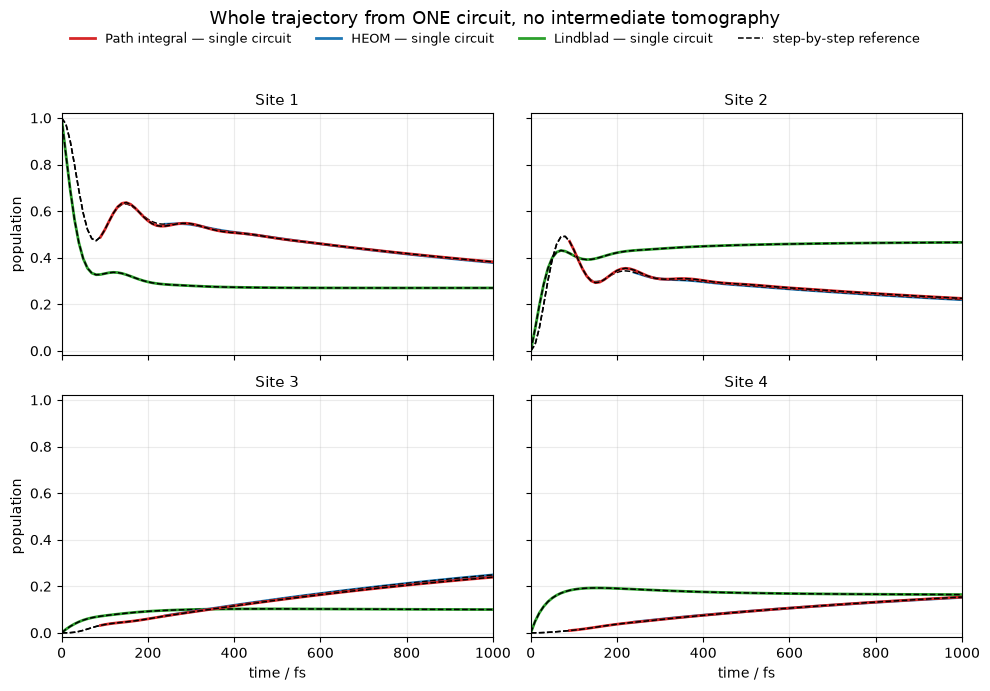

wrote pictures/single_grid_N4.png


In [6]:
col = {'Lindblad': '#2ca02c', 'HEOM': '#1f77b4', 'Path integral': '#d62728'}
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=True, sharey=True)
for site, ax in enumerate(axes.flat):
    ax.plot(t_fs, pops_A[:, site], color=col['Lindblad'], lw=2.0)
    ax.plot(t_fs, res['Lindblad']['pops'][:, site], color='k', ls='--', lw=1.1)
    for name in ('HEOM', 'Path integral'):
        K = res[name]['K']
        ax.plot(t_fs[K - 1:], out_B[name][0][:, site], color=col[name], lw=2.0)
        ax.plot(t_fs, res[name]['pops'][:, site], color='k', ls='--', lw=1.1)
    ax.set_title(f'Site {site + 1}', fontsize=11)
    ax.set_xlim(0, t_fs[-1]); ax.set_ylim(-0.02, 1.02); ax.grid(alpha=0.25)
    if site >= 2: ax.set_xlabel('time / fs')
    if site % 2 == 0: ax.set_ylabel('population')

from matplotlib.lines import Line2D
handles = [Line2D([], [], color=col[n], lw=2.0,
                  label=f'{n} — single circuit') for n in ('Path integral', 'HEOM', 'Lindblad')]
handles.append(Line2D([], [], color='k', ls='--', lw=1.1, label='step-by-step reference'))
fig.legend(handles=handles, loc='upper center', ncol=4, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, 0.965))
fig.suptitle('Whole trajectory from ONE circuit, no intermediate tomography', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.93])
fig.savefig(f'pictures/single_grid_N{N}.png', dpi=200); plt.show()
print(f'wrote pictures/single_grid_N{N}.png')

## The two grids, drawn next to their formulas

Below are the circuits themselves, truncated to three steps so the repeating unit is legible. Each
element corresponds to one object from the theory.

**Left — route A, the deterministic grid of §4.** The register `sys` carries $\rho$ itself on
$n_{\rm sys}=\lceil\log_2 d\rceil=2$ qubits; `env` is the $n_{\rm env}=\lceil\log_2K\rceil=4$ qubit
environment of the Stinespring dilation. The box $U_S$ is the unitary completion
$U=[\,V\,|\,w_1\cdots\,]$ with $V|\psi\rangle=\sum_k|k\rangle_E\otimes M_k|\psi\rangle$, and it is
applied to `sys` first and `env` second precisely to realise the index convention
$\text{index}=k\cdot2^{n_{\rm sys}}+i$. The $|0\rangle$ symbols on the `env` wires are the resets, i.e.
the partial trace $\operatorname{Tr}_E$ that turns $U$ back into the channel $\Phi$. There is no meter
anywhere: every step has probability $1$, and the state on `sys` after $t$ repetitions is
$\Phi^t(\rho_0)$.

**Right — route B, the post-selected grid of §5–§6.** The register `mem` holds the *normalised Krylov
coefficient vector* $y_t$ on $\lceil\log_2m\rceil=5$ qubits — not $\rho$ itself, but the compressed
representation of the whole history window $X_t$ through $\operatorname{vec}\rho_t=\lambda_t\Pi Q_my_t$.
The box $U_H$ is the Sz.-Nagy dilation of $H_m/s$ with $s=\|H_m\|_2=1.0028$, and `anc` is its single
ancilla. Here a meter *does* appear on `anc` after every step: that is the post-selection on
$|0\rangle$ which projects onto the $(H_m/s)y_t$ branch with probability $p_t$. The meter never touches
`mem`, and `mem` is never re-prepared — the state simply continues. The reset returns `anc` to
$|0\rangle$ so the same ancilla can serve the next step.

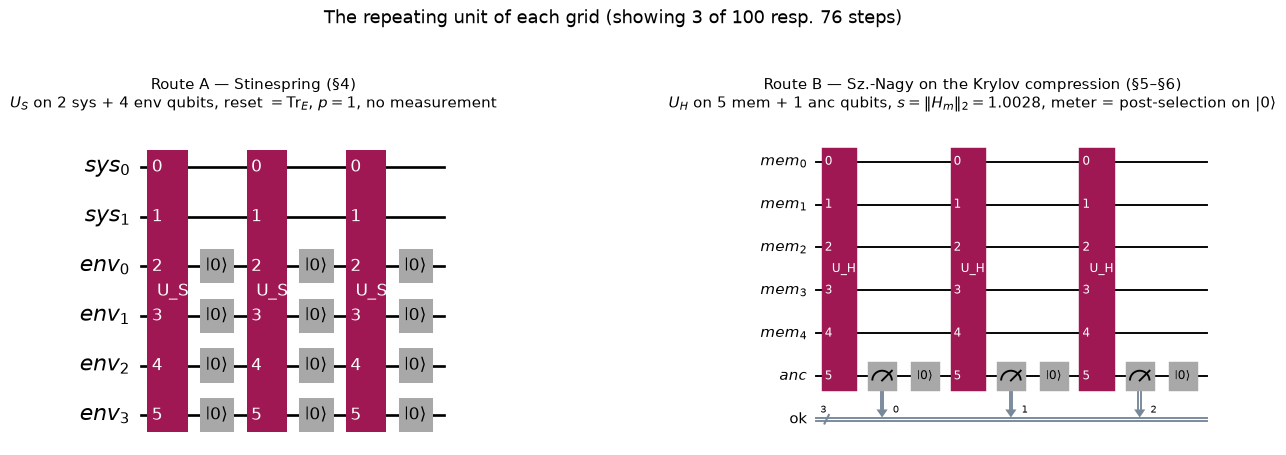

wrote pictures/single_grid_circuits_N4.png


In [7]:
SHOW_STEPS = 3          # the repeating unit; the real circuits have 100 resp. 76 of these

# ---- route A: sys (rho itself) + env, U_S, reset, no meter --------------
U_A, ns_A, ne_A = stinespring_unitary(res['Lindblad']['kraus_dt'], d)
sysA, envA = list(range(ns_A)), list(range(ns_A, ns_A + ne_A))
qc_A_show = QuantumCircuit(QuantumRegister(ns_A, 'sys'), QuantumRegister(ne_A, 'env'))
for _ in range(SHOW_STEPS):
    qc_A_show.append(UnitaryGate(U_A, label='U_S'), sysA + envA)
    qc_A_show.reset(envA)

# ---- route B: mem (Krylov vector y_t) + anc, U_H, meter, reset ----------
E, K = res['HEOM']['E'], res['HEOM']['K']
X0 = np.concatenate([res['HEOM']['rho'][i].flatten(order='F') for i in range(K)][::-1])
Hm, Qm = arnoldi(E, X0, M_KRYLOV)
mp = 1 << int(np.ceil(np.log2(Hm.shape[0])))
A_pad = np.zeros((mp, mp), complex); A_pad[:Hm.shape[0], :Hm.shape[0]] = Hm
U_B, s_B = dilate(A_pad)
nq_B = int(np.log2(mp))
memB, ancB = QuantumRegister(nq_B, 'mem'), QuantumRegister(1, 'anc')
qc_B_show = QuantumCircuit(memB, ancB, ClassicalRegister(SHOW_STEPS, 'ok'))
for t in range(SHOW_STEPS):
    qc_B_show.append(UnitaryGate(U_B, label='U_H'), list(memB) + list(ancB))
    qc_B_show.measure(ancB[0], t)
    qc_B_show.reset(ancB[0])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
qc_A_show.draw(output='mpl', ax=axes[0])
axes[0].set_title(f'Route A — Stinespring (§4)\n'
                  f'$U_S$ on {ns_A} sys + {ne_A} env qubits, reset $=\\mathrm{{Tr}}_E$, '
                  f'$p=1$, no measurement', fontsize=11, pad=14)
qc_B_show.draw(output='mpl', ax=axes[1])
axes[1].set_title(f'Route B — Sz.-Nagy on the Krylov compression (§5–§6)\n'
                  f'$U_H$ on {nq_B} mem + 1 anc qubits, $s=\\|H_m\\|_2={s_B:.4f}$, '
                  f'meter = post-selection on $|0\\rangle$', fontsize=11, pad=14)
fig.suptitle(f'The repeating unit of each grid (showing {SHOW_STEPS} of '
             f'{len(t_fs)-1} resp. {len(t_fs)-K} steps)', fontsize=13)
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig(f'pictures/single_grid_circuits_N{N}.png', dpi=200); plt.show()
print(f'wrote pictures/single_grid_circuits_N{N}.png')